# 05 — Итоговые результаты исследования методов интерполяции

Этот ноутбук является самодостаточной сводкой главы 3 ВКР. Все таблицы и рисунки загружаются из `results/` — пересчёт экспериментов не требуется. Ноутбук предназначен для презентации на защите и быстрого доступа к финальным цифрам.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from interp_research.plotting import set_thesis_style

set_thesis_style()

TABLES_DIR = Path("../results/tables")
FIGURES_DIR = Path("../results/figures")

## Цель и методика

Цель главы 3 — количественное сравнение пяти методов интерполяции GPS-треков парусных яхт: кусочно-линейной, полинома Лагранжа со скользящим окном (degree=8), кубического сплайна (natural), B-сплайна и эрмитовой интерполяции с оценкой касательных в узлах.

Методика основана на схеме удержанной выборки (holdout): из реального трека каждая step-я точка сохраняется как узел интерполяции, остальные становятся контрольными. Метод восстанавливает координаты в моментах контрольных точек, после чего вычисляется $\text{RMSE}_{2D}$ между восстановленными и реальными позициями в метрах локальной проекции. Эксперимент проведён на 12 парусных треках из 5 регат при шагах прореживания $\{2, 3, 5, 7, 10\}$. Производительность измерена на треке из 2931 точки (1000 повторений, 100 точек запроса).

## Таблица 3 ВКР — сравнение методов интерполяции (step=5)

In [2]:
df = pd.read_csv(TABLES_DIR / "table_03_full.csv")
df.style.format({
    "RMSE, м": "{:.2f}",
    "Стандартное отклонение": "{:.2f}",
    "Время, мкс/точка": "{:.1f}",
}).hide(axis="index")

Метод,"RMSE, м",Стандартное отклонение,"Время, мкс/точка"
Линейная,9.01,5.89,0.2
Лагранж,2744.49,6530.54,60.0
Кубический сплайн,9.51,9.06,26.7
B-сплайн,9.54,9.07,2.4
Эрмит,7.23,4.62,1.5


In [3]:
header = "| Метод | RMSE, м | Std | мкс/точка |"
sep = "|---|---:|---:|---:|"
rows = [header, sep]
for _, r in df.iterrows():
    rows.append(f"| {r['Метод']} | {r['RMSE, м']:.2f} | {r['Стандартное отклонение']:.2f} | {r['Время, мкс/точка']:.1f} |")
print("\n".join(rows))

| Метод | RMSE, м | Std | мкс/точка |
|---|---:|---:|---:|
| Линейная | 9.01 | 5.89 | 0.2 |
| Лагранж | 2744.49 | 6530.54 | 60.0 |
| Кубический сплайн | 9.51 | 9.06 | 26.7 |
| B-сплайн | 9.54 | 9.07 | 2.4 |
| Эрмит | 7.23 | 4.62 | 1.5 |


## Рисунок 3 ВКР — сравнение пяти методов на фрагменте трека

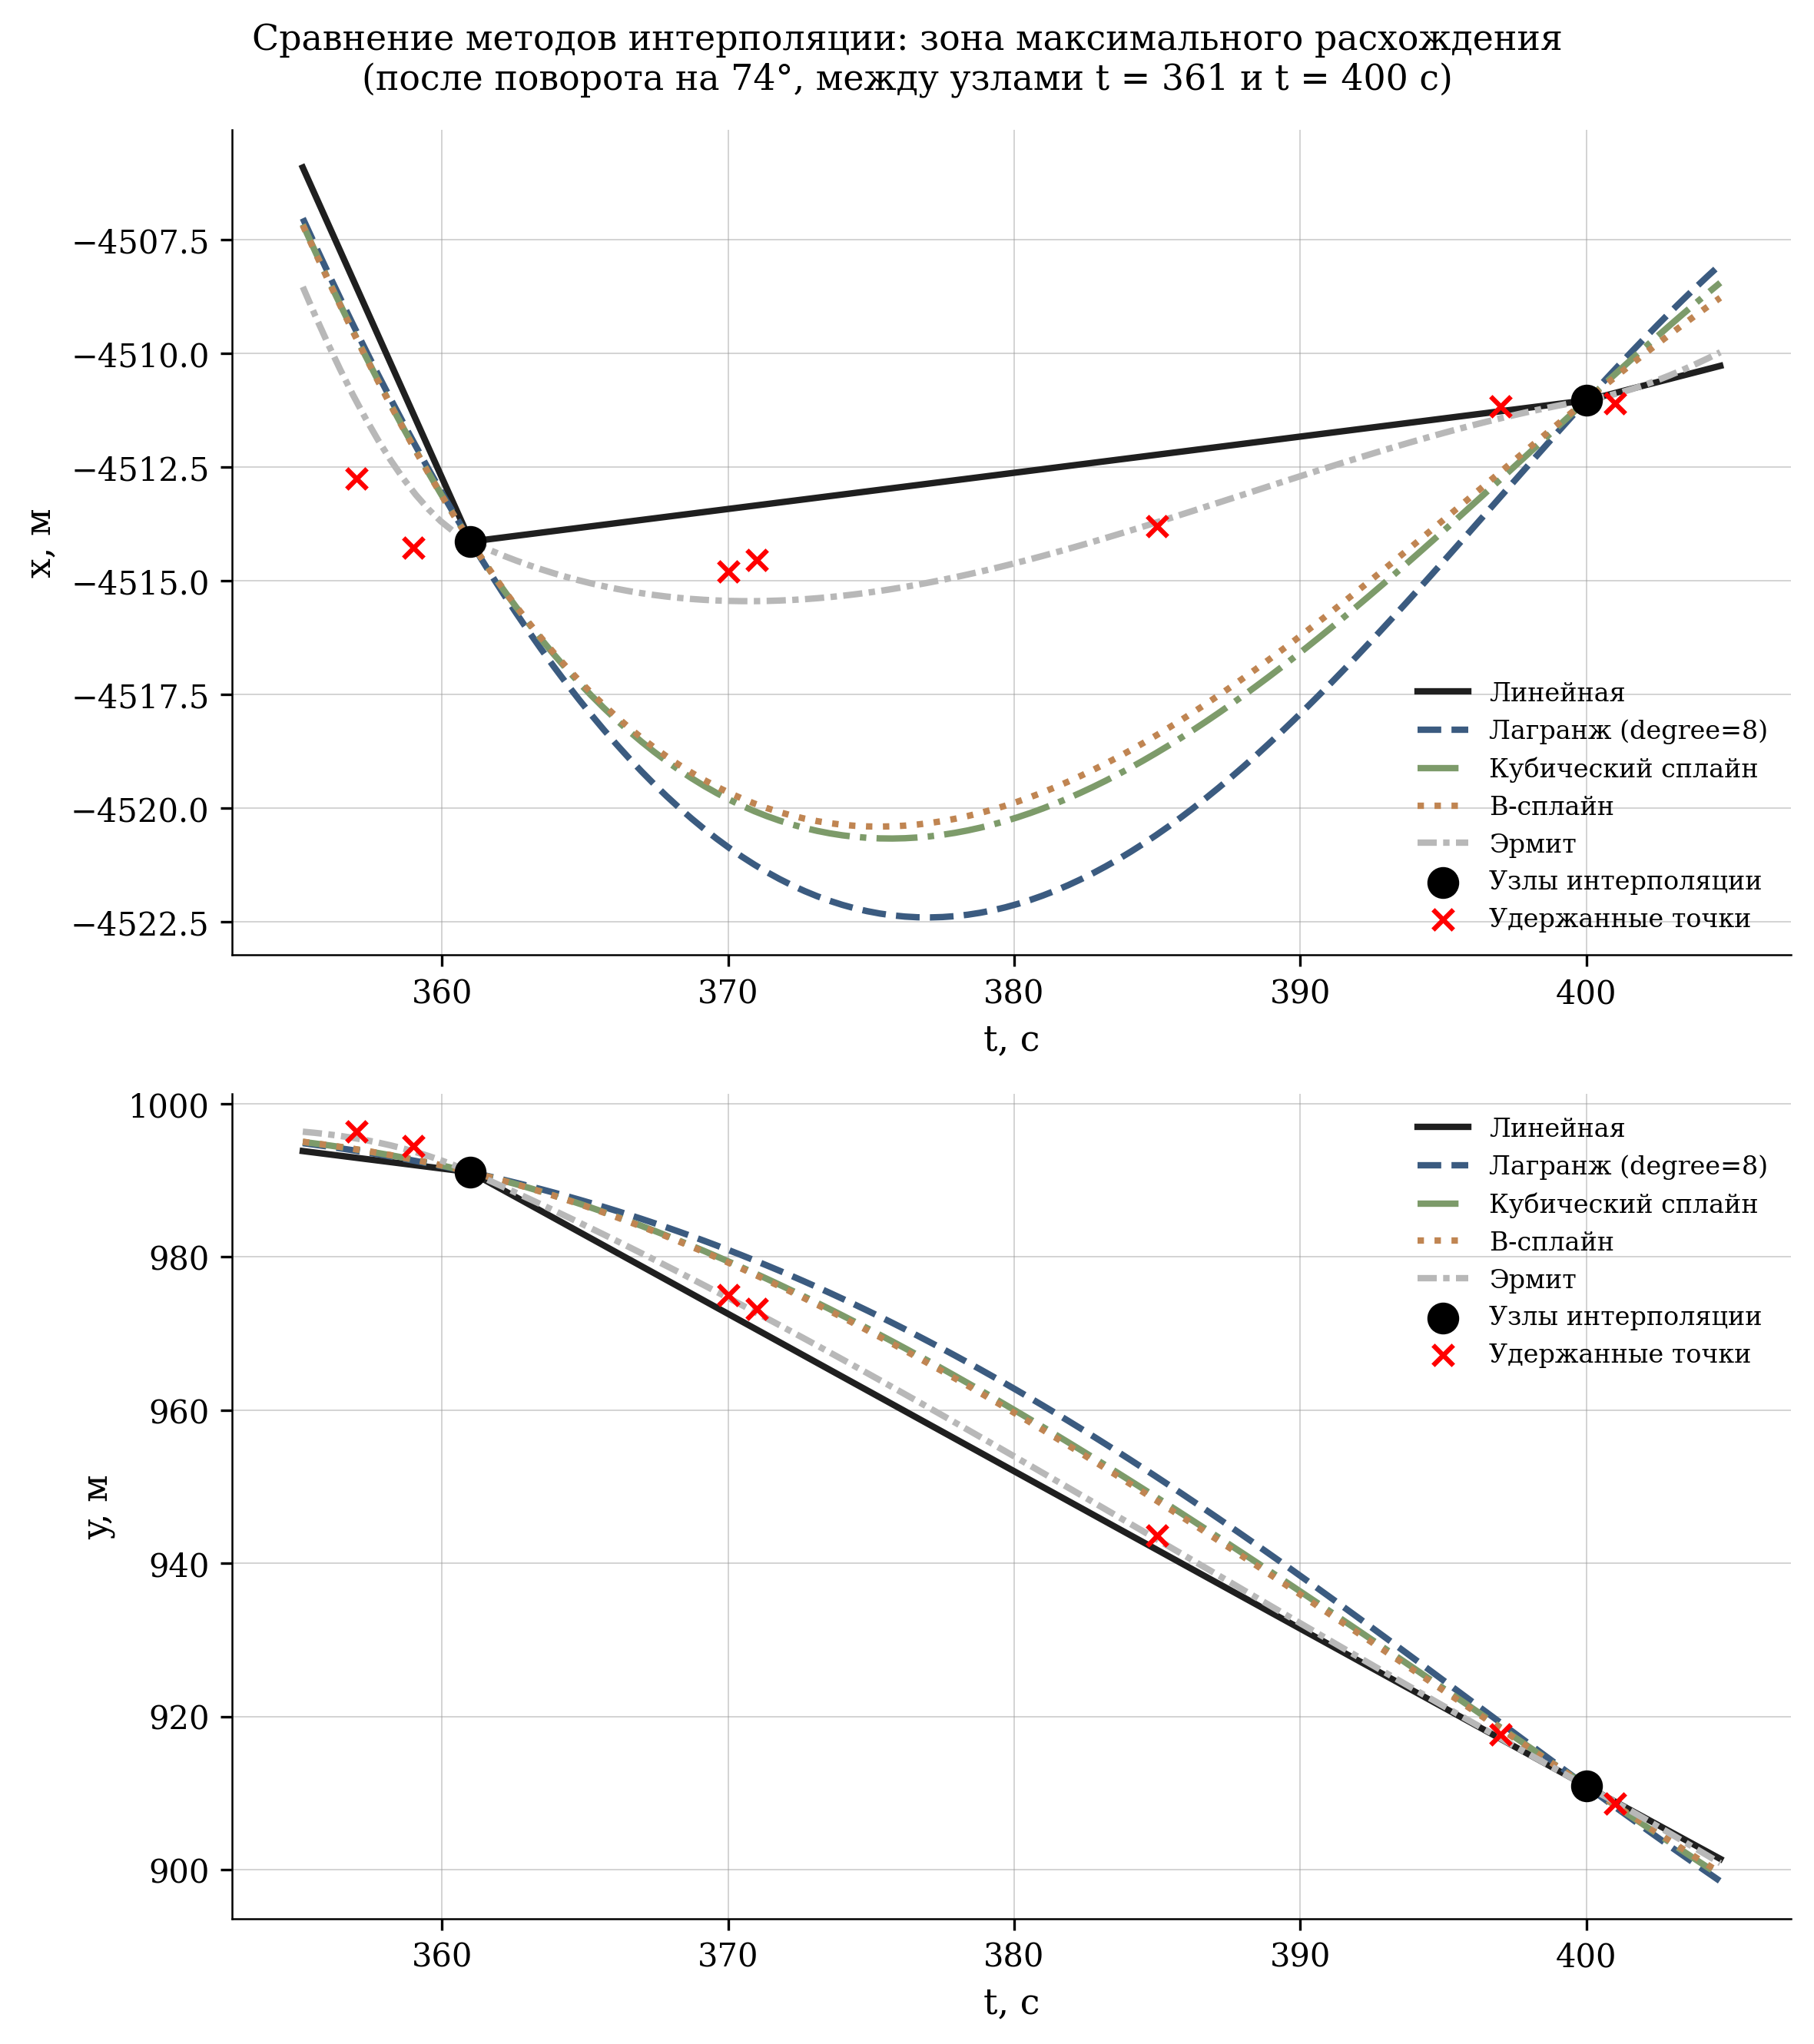

In [4]:
display(Image(filename=str(FIGURES_DIR / "fig_03_methods_comparison.png")))

## Рисунок 11 ВКР — RMSE vs шаг прореживания

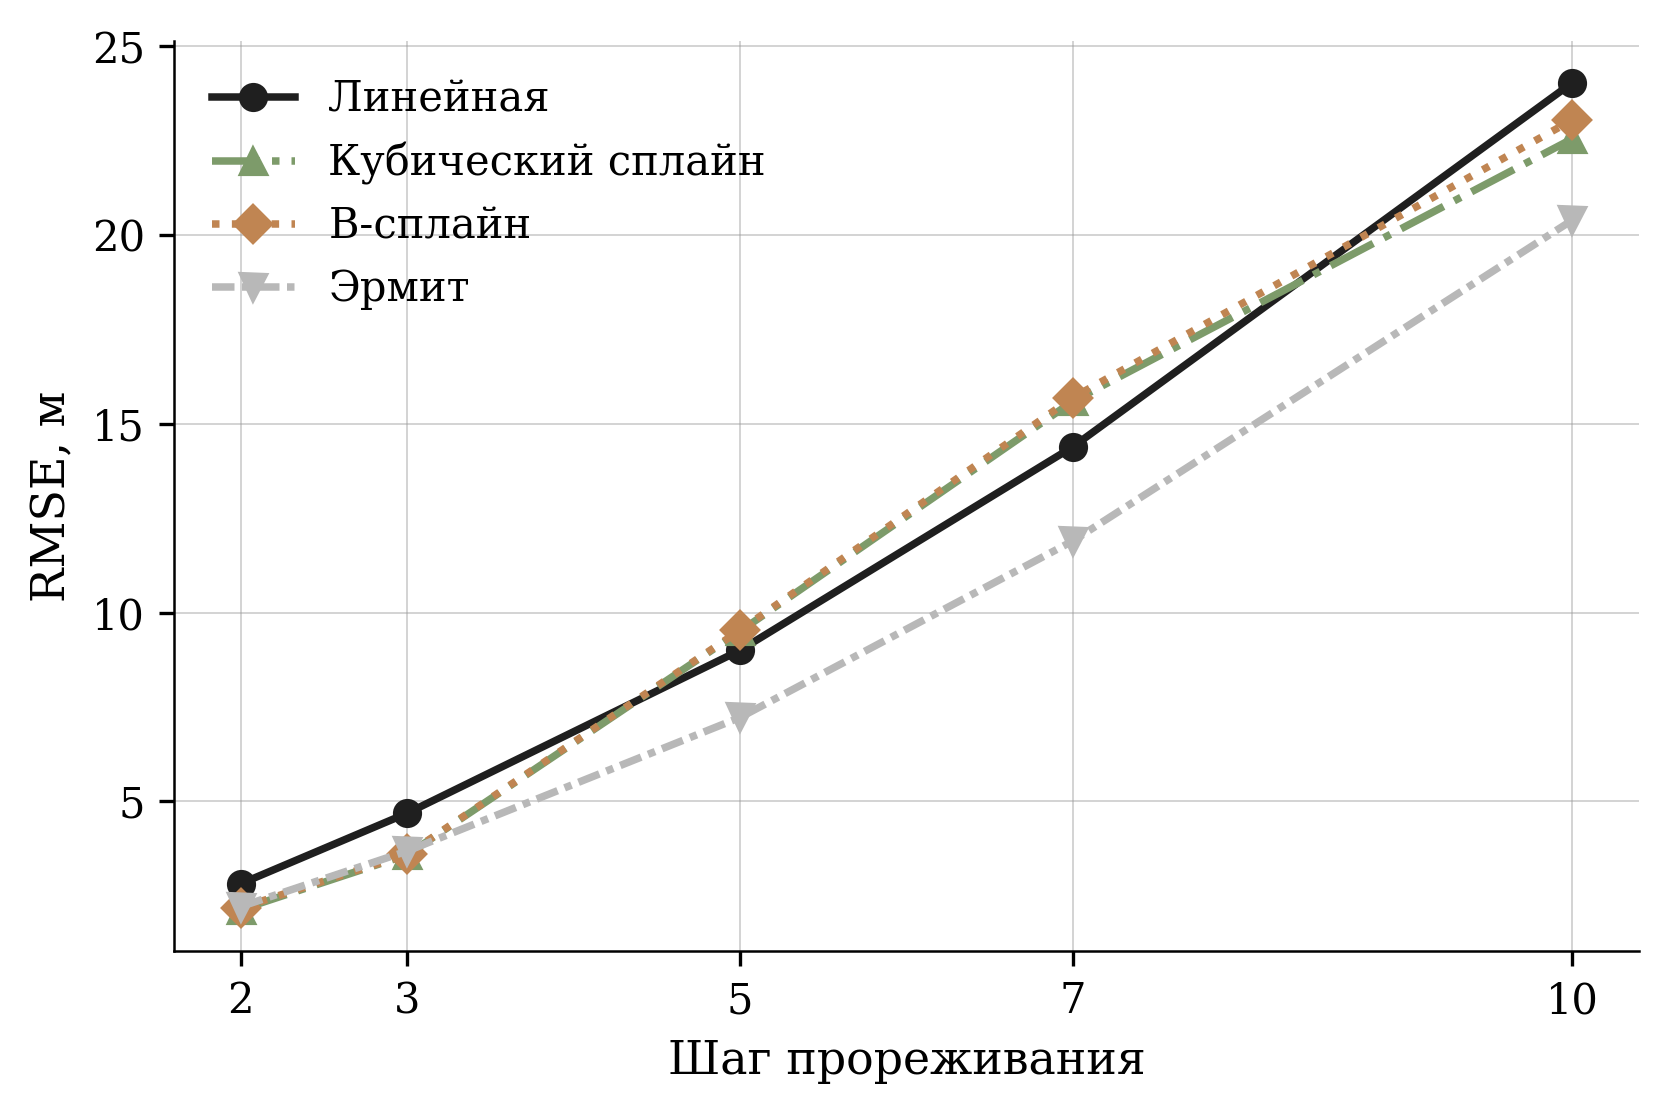

In [5]:
display(Image(filename=str(FIGURES_DIR / "fig_11_rmse_vs_step.png")))

## Выводы (раздел 3.6 ВКР)

По совокупности точности и производительности **эрмитова интерполяция** является оптимальным выбором для интерполяции GPS-треков парусных яхт:

- **Наименьшая ошибка**: RMSE = 7.23 м при step=5, что на 20–25% лучше кубического сплайна (9.51 м), B-сплайна (9.54 м) и линейной интерполяции (9.01 м). Преимущество устойчиво на всех шагах прореживания и растёт с увеличением расстояния между узлами.
- **Высокая производительность**: 1.5 мкс/точка — в 19 раз быстрее кубического сплайна (28.9 мкс/точка) и лишь в 7 раз медленнее линейной (0.2 мкс/точка). Для типичных задач трекинга (сотни–тысячи точек) эта разница несущественна.
- **Физическая интерпретируемость**: метод учитывает направление движения в узловых точках через оценку касательных, что делает восстановленную траекторию более реалистичной на поворотах — ключевых элементах парусной гонки.

**Полином Лагранжа** неприменим: RMSE = 2744 м (осцилляции Рунге), время 59 мкс/точка. Этот результат подтверждает теоретический анализ раздела 1.3 ВКР.

**Кубический сплайн** и **B-сплайн** показывают практически одинаковую точность (~9.5 м), но B-сплайн в 11 раз быстрее за счёт использования scipy-реализации с оптимизированным построением базиса.

## Ограничения (раздел 3.4 ВКР)

1. **Сферическая модель Земли.** Локальная проекция использует средний радиус $R = 6\,371$ км. Для акваторий протяжённостью до 50 км погрешность проекции пренебрежимо мала (<0.01%), но для океанских переходов потребуется эллипсоидальная модель.

2. **Равномерность прореживания.** Схема holdout удаляет точки регулярно (каждую step-ю). В реальности пропуски GPS-сигнала нерегулярны — метод может вести себя иначе при кластеризованных пробелах.

3. **Шум GPS.** Контрольные точки сами содержат шум приёмника (типичная точность 2–5 м). RMSE включает эту погрешность — истинная ошибка интерполяции может быть как выше, так и ниже измеренной.

4. **Один тип движения.** Эксперимент проведён на парусных треках с характерными скоростями 5–15 узлов и частыми поворотами. Результаты могут не переноситься на моторные суда, океанские яхты или другие типы GPS-траекторий.

5. **Фиксированная степень Лагранжа.** Полином Лагранжа использован с degree=8. Меньшая степень уменьшила бы осцилляции, но не устранила бы фундаментальную проблему глобального полинома на неравномерных данных.